# **Implementation of Convolutional Neural Network using Keras.**

In [ ]:
import tensorflow as tf
import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/AI and ML/Week5/Copy of FruitinAmazon.zip'
extract_to = '/content/drive/MyDrive/AI and ML/Week5/FruitinAmazon'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("ZIP file extracted to:", extract_to)

ZIP file extracted to: /content/drive/MyDrive/AI and ML/Week5/FruitinAmazon


# Task 1: Data Understanding and Visualization:

Classes found: ['pupunha', 'acai', 'guarana', 'graviola', 'tucuma', 'cupuacu']


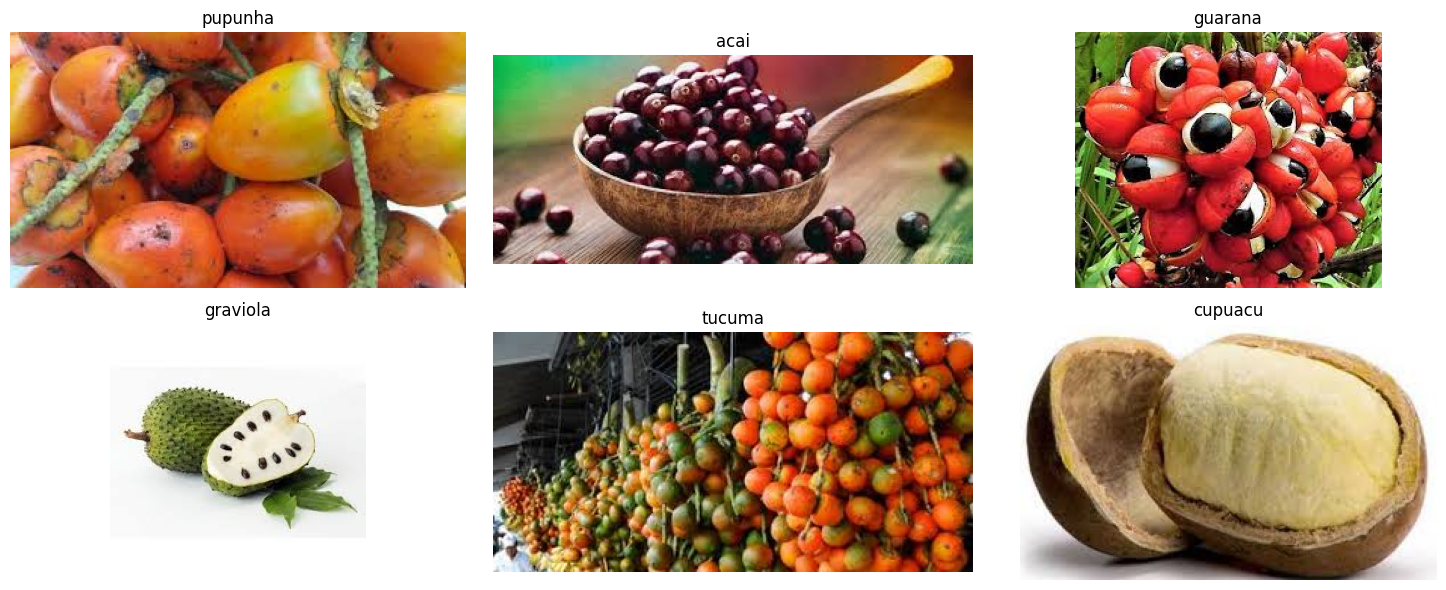

In [ ]:
# 1. Load and visualize images from a dataset stored in directories, where each subdirec-tory represents a class.
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to your dataset (train folder)
train_dir = '/content/drive/MyDrive/AI and ML/Week5/FruitinAmazon/FruitinAmazon/train'

# Get list of class directories
classes = [cls for cls in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, cls))]

print("Classes found:", classes)

# Select one random image from each class
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_files = os.listdir(class_path)

    if len(img_files) == 0:
        continue

    img_name = random.choice(img_files)
    img_path = os.path.join(class_path, img_name)

    images.append(img_path)
    labels.append(cls)

# Display images in a grid (2 rows)
num_images = len(images)
cols = (num_images + 1) // 2  # ensure 2 rows

plt.figure(figsize=(15, 6))

for i, img_path in enumerate(images):
    plt.subplot(2, cols, i + 1)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

**What did you Observe?**

The dataset consists of 6 classes (pupunha, acai, guarana, graviola, tucuma, cupuacu), each stored in separate folders. The images show noticeable visual differences in color and shape across classes, making it suitable for a multi-class classification task, although some similarities may introduce minor classification challenges.

In [ ]:
# 2. Check for Corrupted Image
corrupted_images = []

# Iterate through each class folder
for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    if not os.path.isdir(class_path):
        continue

    # Iterate through each image in the class folder
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            # Try opening the image
            with Image.open(img_path) as img:
                img.verify()  # verify checks for corruption

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


# Task 2: Loading and Preprocessing Image Data in keras:

In [ ]:
import tensorflow as tf

# Define parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization
val_ds = val_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3 - Implement a CNN with

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Number of classes
num_classes = 6

# Build CNN model
model = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(32, (3,3), strides=1, padding='same', input_shape=(128,128,3)),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Convolution Layer 2
    layers.Conv2D(32, (3,3), strides=1, padding='same'),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Fully Connected Layers
    layers.Flatten(),

    layers.Dense(64, activation='relu'),   # Hidden Layer 1
    layers.Dense(128, activation='relu'),  # Hidden Layer 2

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])
# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Params=(Kernel Height×Kernel Width×Input Channels×Number of Filters)+Bias

# Task 4: Compile the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 5: Train the Model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Callbacks
checkpoint = ModelCheckpoint(
    "best_model.h5",            # Save best model
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,               # Stop if no improvement for 10 epochs
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=batch_size,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.2049 - loss: 2.0117


Epoch 1: val_accuracy improved from None to 0.22222, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 645ms/step - accuracy: 0.2083 - loss: 2.0853 - val_accuracy: 0.2222 - val_loss: 1.4575
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.2477 - loss: 1.8431
Epoch 2: val_accuracy improved from 0.22222 to 0.72222, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 465ms/step - accuracy: 0.3056 - loss: 1.8035 - val_accuracy: 0.7222 - val_loss: 1.5820
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.2894 - loss: 1.6724
Epoch 3: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step - accuracy: 0.3056 - loss: 1.6280 - val_accuracy: 0.0000e+00 - val_loss: 1.8057
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.3131 - loss: 1.5257
Epoch 4: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 535ms/step - accuracy: 0.3611 - loss: 1.5001 - val_accuracy: 0.2778 - val_loss: 1.5774
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.5804 - loss: 1.2571
Epoch 5: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 652ms/step - accuracy: 0.5694 - loss: 1.2685 - val_accuracy: 0.6667 - val_loss: 1.3258
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.6806 - loss: 1


Epoch 6: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 559ms/step - accuracy: 0.6667 - loss: 1.0670 - val_accuracy: 0.7778 - val_loss: 1.1119
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9207 - loss: 0.7580
Epoch 7: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 433ms/step - accuracy: 0.9028 - loss: 0.7804 - val_accuracy: 0.5556 - val_loss: 1.1815
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8391 - loss: 0.6107
Epoch 8: val_accuracy improved from 0.77778 to 0.88889, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 0.8611 - loss: 0.5758 - val_accuracy: 0.8889 - val_loss: 0.6208
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.8819 - loss: 0.3949
Epoch 9: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 415ms/step - accuracy: 0.8333 - loss: 0.4501 - val_accuracy: 0.8333 - val_loss: 0.5723
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9699 - loss: 0.2671
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 418ms/step - accuracy: 0.9722 - loss: 0.2625 - val_accuracy: 0.5556 - val_loss: 1.0246
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9149 - loss: 0.2761
Epoch 11: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 427ms/step - accuracy: 0.9167 - loss: 0.2546 - val_accuracy: 0.8333 - val_loss: 0.5977
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.9398 - loss: 

# Task 6: Evaluate the Model

In [ ]:
test_dir = '/content/drive/MyDrive/AI and ML/Week5/FruitinAmazon/FruitinAmazon/test'

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = test_ds.class_names
# Normalize
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.7000 - loss: 1.5340
Test Loss: 1.5340
Test Accuracy: 0.7000


# Task 7: Save and Load the Model

In [ ]:
from tensorflow.keras.models import load_model

# Save the model
model.save("final_model.h5")
print("Model saved successfully!")

# Load the model
loaded_model = load_model("final_model.h5")
print("Model loaded successfully!")

# Evaluate loaded model
test_loss, test_accuracy = loaded_model.evaluate(test_ds)

print(f"Loaded Model Test Loss: {test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {test_accuracy:.4f}")

Model saved successfully!
Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step - accuracy: 0.7000 - loss: 1.5340
Loaded Model Test Loss: 1.5340
Loaded Model Test Accuracy: 0.7000


# Task 8: Predictions and Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Get predictions (probabilities)
y_pred_probs = model.predict(test_ds)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
Classification Report:
               precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.57      0.80      0.67         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.83      1.00      0.91         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.70        30
   macro avg       0.73      0.70      0.70        30
weighted avg       0.73      0.70      0.70        30



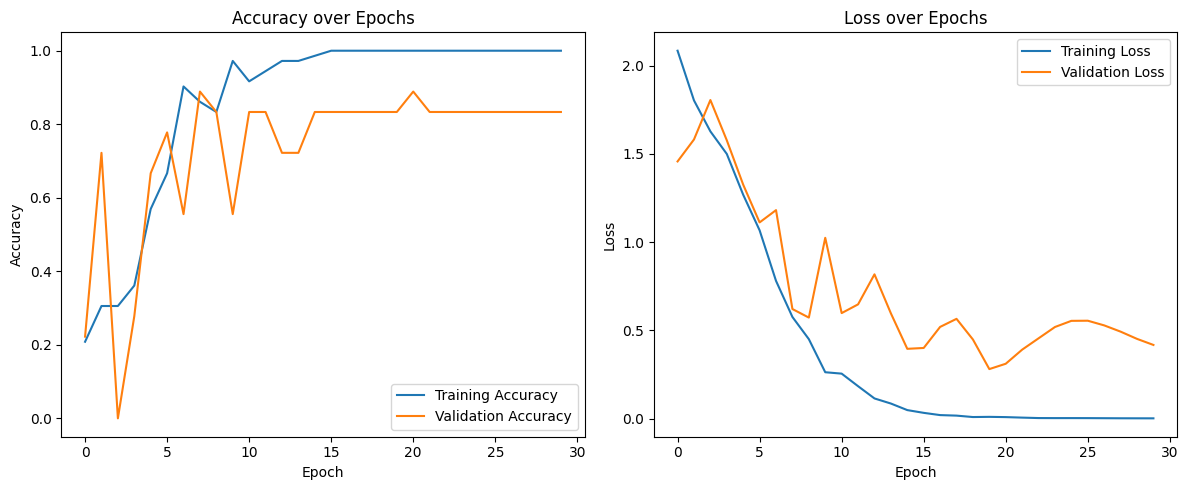

In [ ]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.tight_layout()
plt.show()